# Input modality: how should multiplexed data be fed to a model?

Compares four ways of feeding the channels to a model, on the selected arm: Max-Projection (baseline), a learned
1x1 adapter, a widened first layer taking all channels (multiplexed input), and the tuned ChannelNet adaptor.
4 models x 4 datasets x 5 folds. Scores come from `results/all_runs.csv` (`validation/consolidate.py`).

In [1]:
import sys
from pathlib import Path

BENCH_DIR = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if p.name == "bench")
sys.path.insert(0, str(BENCH_DIR))

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from validation.consolidate import DATASETS, N_FOLDS, load
from figures.utils import stars

matplotlib.rcParams["pdf.fonttype"] = 42
EXPORT_DIR = BENCH_DIR / "figures" / "export"

METRICS = ["PQ", "F1", "mIoU"]
MODEL_ORDER = ["Cellpose", "InstanSeg", "Stardist", "Dist U-Net"]
MODALITY_ORDER = ["MaxProj", "1x1", "Input", "ChannelNetTuned"]
MODALITY_LABELS = {
    "MaxProj": "Max-Projection",
    "1x1": "1x1 Adapter",
    "Input": "Multiplexed Input",
    "ChannelNetTuned": "ChannelNet (tuned)",
}
PALETTE = {"MaxProj": "#D3D962", "1x1": "#6AB0B8", "Input": "#87B86A", "ChannelNetTuned": "#D173BE"}

## Load

In [2]:
scores = load()  # one row per test image of every run
scores = scores[
    (scores["Arm"] == "selected") & scores["Model"].isin(MODEL_ORDER) & scores["Modality"].isin(MODALITY_ORDER)
]

# Mean score per fold: one value per (model, dataset, modality, fold)
fold_means = scores.groupby(["Model", "Dataset", "Modality", "Fold"], as_index=False)[METRICS].mean()

assert len(fold_means) == len(MODEL_ORDER) * len(DATASETS) * len(MODALITY_ORDER) * N_FOLDS, "some runs are missing"
fold_means.head()

,Model,Dataset,Modality,Fold,PQ,F1,mIoU
0,Cellpose,CODEX,1x1,0,0.541124,0.777006,0.696333
1,Cellpose,CODEX,1x1,1,0.509875,0.741749,0.687383
2,Cellpose,CODEX,1x1,2,0.526852,0.769253,0.685087
3,Cellpose,CODEX,1x1,3,0.501631,0.725148,0.690037
4,Cellpose,CODEX,1x1,4,0.527731,0.755534,0.698536


## Statistics: ANOVA, then Tukey HSD (per model)

Per model, on the 20 fold means per modality: Type II ANOVA `metric ~ Modality + Dataset`, then Tukey HSD on the
dataset-adjusted values (dataset effect removed, grand mean added back). The stars in the bar plot mark MaxProj
vs. each other modality.

In [3]:
tukey_stars = {}  # (metric, model) -> {modality: stars}, MaxProj vs. that modality

for metric in METRICS:
    for model in MODEL_ORDER:
        sub = fold_means[fold_means["Model"] == model]

        anova = anova_lm(ols(f"{metric} ~ C(Modality) + C(Dataset)", data=sub).fit(), typ=2)
        print(f"=== {metric} | {model}: ANOVA (Type II) ===")
        display(anova)

        # Tukey on values with the dataset effect removed
        dataset_fit = ols(f"{metric} ~ C(Dataset)", data=sub).fit()
        adjusted = sub[metric] - dataset_fit.fittedvalues + sub[metric].mean()
        tukey = pairwise_tukeyhsd(endog=adjusted, groups=sub["Modality"], alpha=0.05)

        table = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
        table = table[table["group2"] == "MaxProj"]  # MaxProj sorts last, so it is always group2
        table = table.assign(other=table["group1"], stars=table["p-adj"].apply(stars))
        print(f"--- {metric} | {model}: Tukey HSD, MaxProj vs. others (meandiff = MaxProj - other) ---")
        display(table[["other", "meandiff", "p-adj", "stars"]].reset_index(drop=True))

        tukey_stars[(metric, model)] = dict(zip(table["other"], table["stars"]))

=== PQ | Cellpose: ANOVA (Type II) ===


,sum_sq,df,F,PR(>F)
C(Modality),0.021960,3.0,7.322376,0.000233
C(Dataset),0.018958,3.0,6.321367,0.000716
Residual,0.072976,73.0,NaN,NaN


--- PQ | Cellpose: Tukey HSD, MaxProj vs. others (meandiff = MaxProj - other) ---


,other,meandiff,p-adj,stars
0,1x1,0.0276,0.0309,*
1,ChannelNetTuned,0.0463,0.0001,***
2,Input,0.0290,0.0209,*


=== PQ | InstanSeg: ANOVA (Type II) ===


...

,other,meandiff,p-adj,stars
0,1x1,0.0269,0.0000,***
1,ChannelNetTuned,0.0054,0.6188,ns
2,Input,0.0205,0.0001,***


=== mIoU | Dist U-Net: ANOVA (Type II) ===


,sum_sq,df,F,PR(>F)
C(Modality),0.003136,3.0,4.680718,4.792030e-03
C(Dataset),0.017766,3.0,26.513619,1.046010e-11
Residual,0.016305,73.0,NaN,NaN


--- mIoU | Dist U-Net: Tukey HSD, MaxProj vs. others (meandiff = MaxProj - other) ---


,other,meandiff,p-adj,stars
0,1x1,0.0098,0.1600,ns
1,ChannelNetTuned,0.0167,0.0032,**
2,Input,0.0135,0.0232,*


## Bars per model

Each bar is the mean over 20 points (4 datasets x 5 folds), error bars are the SD. Stars: Tukey HSD vs. MaxProj.

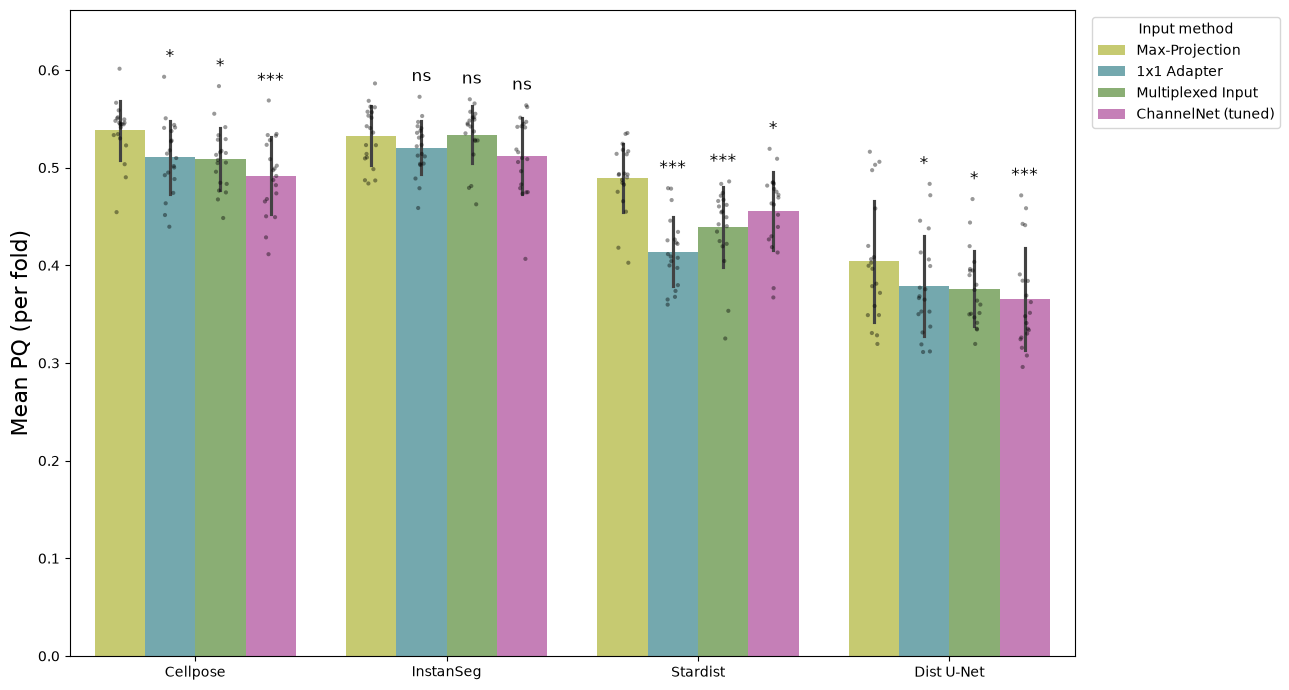

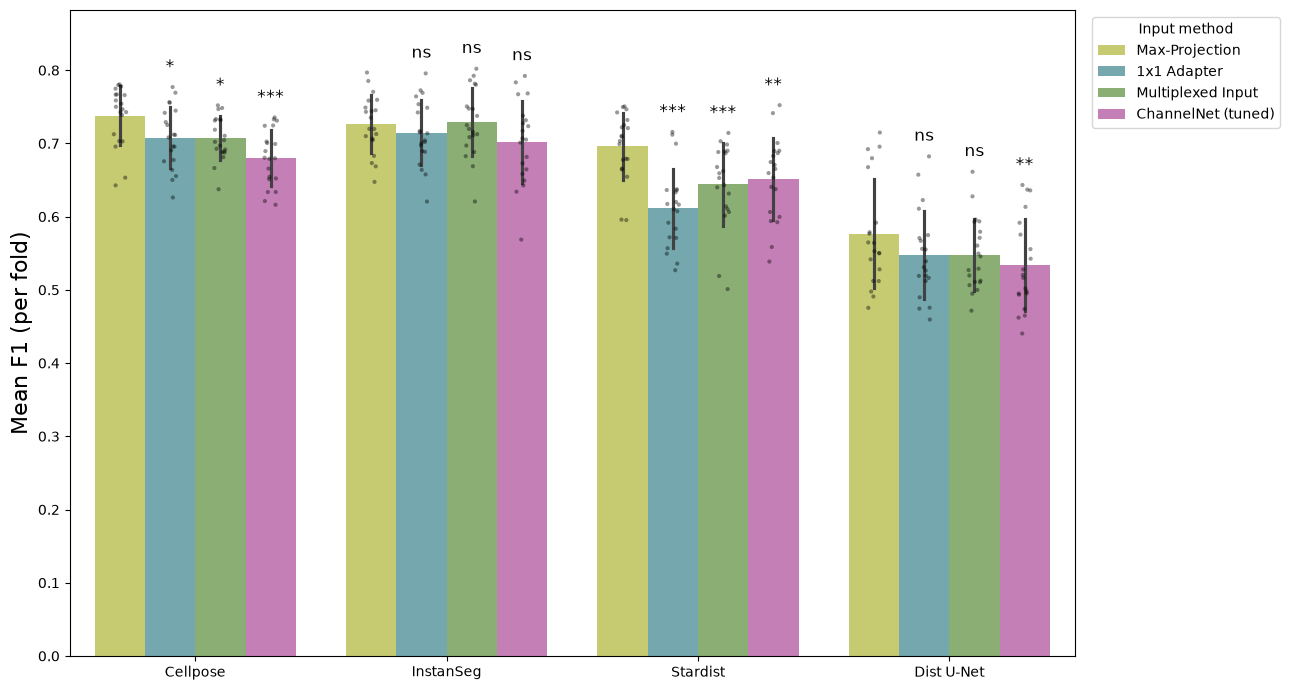

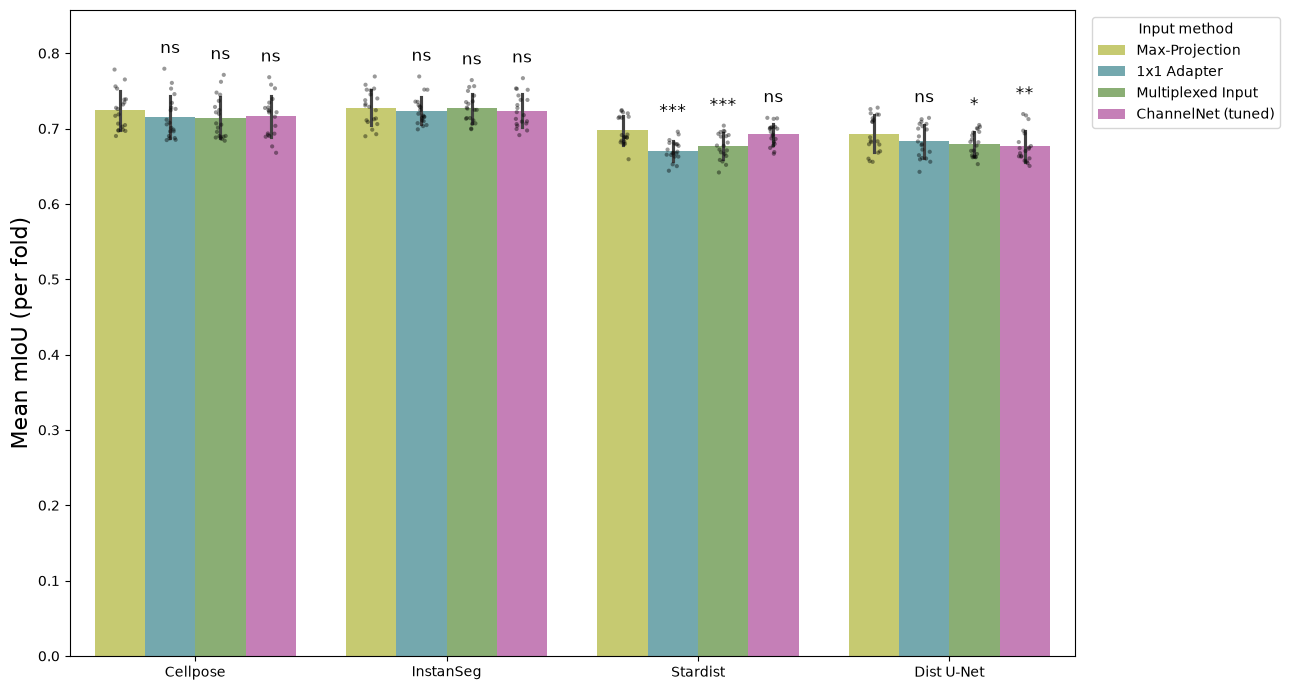

In [4]:
n_mod = len(MODALITY_ORDER)
bar_width = 0.8 / n_mod  # seaborn splits each group's 0.8 width evenly between the hues

for metric in METRICS:
    fig, ax = plt.subplots(figsize=(13, 7))
    sns.barplot(
        data=fold_means, x="Model", y=metric, hue="Modality",
        order=MODEL_ORDER, hue_order=MODALITY_ORDER, palette=PALETTE, errorbar="sd", ax=ax,
    )
    sns.stripplot(
        data=fold_means, x="Model", y=metric, hue="Modality",
        order=MODEL_ORDER, hue_order=MODALITY_ORDER, dodge=True,
        palette=["black"] * n_mod, alpha=0.4, size=3, ax=ax, legend=False,
    )

    # stars above each non-MaxProj modality's points
    y_max = fold_means[metric].max()
    for i, model in enumerate(MODEL_ORDER):
        for j, modality in enumerate(MODALITY_ORDER[1:], start=1):
            x = i + (j - (n_mod - 1) / 2) * bar_width
            top = fold_means[(fold_means["Model"] == model) & (fold_means["Modality"] == modality)][metric].max()
            ax.text(x, top + 0.02 * y_max, tukey_stars[(metric, model)][modality], ha="center", va="bottom", fontsize=12)
    ax.set_ylim(top=y_max * 1.1)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [MODALITY_LABELS[l] for l in labels], title="Input method",
              loc="upper left", bbox_to_anchor=(1.01, 1))
    ax.set_xlabel("")
    ax.set_ylabel(f"Mean {metric} (per fold)", fontsize=16)
    fig.tight_layout()
    fig.savefig(EXPORT_DIR / f"Modality_Overall_{metric}.pdf", bbox_inches="tight")

## Per-image distributions by dataset (no statistics)

Same comparison, but every test image is a point instead of a fold mean. Diamonds mark the mean.

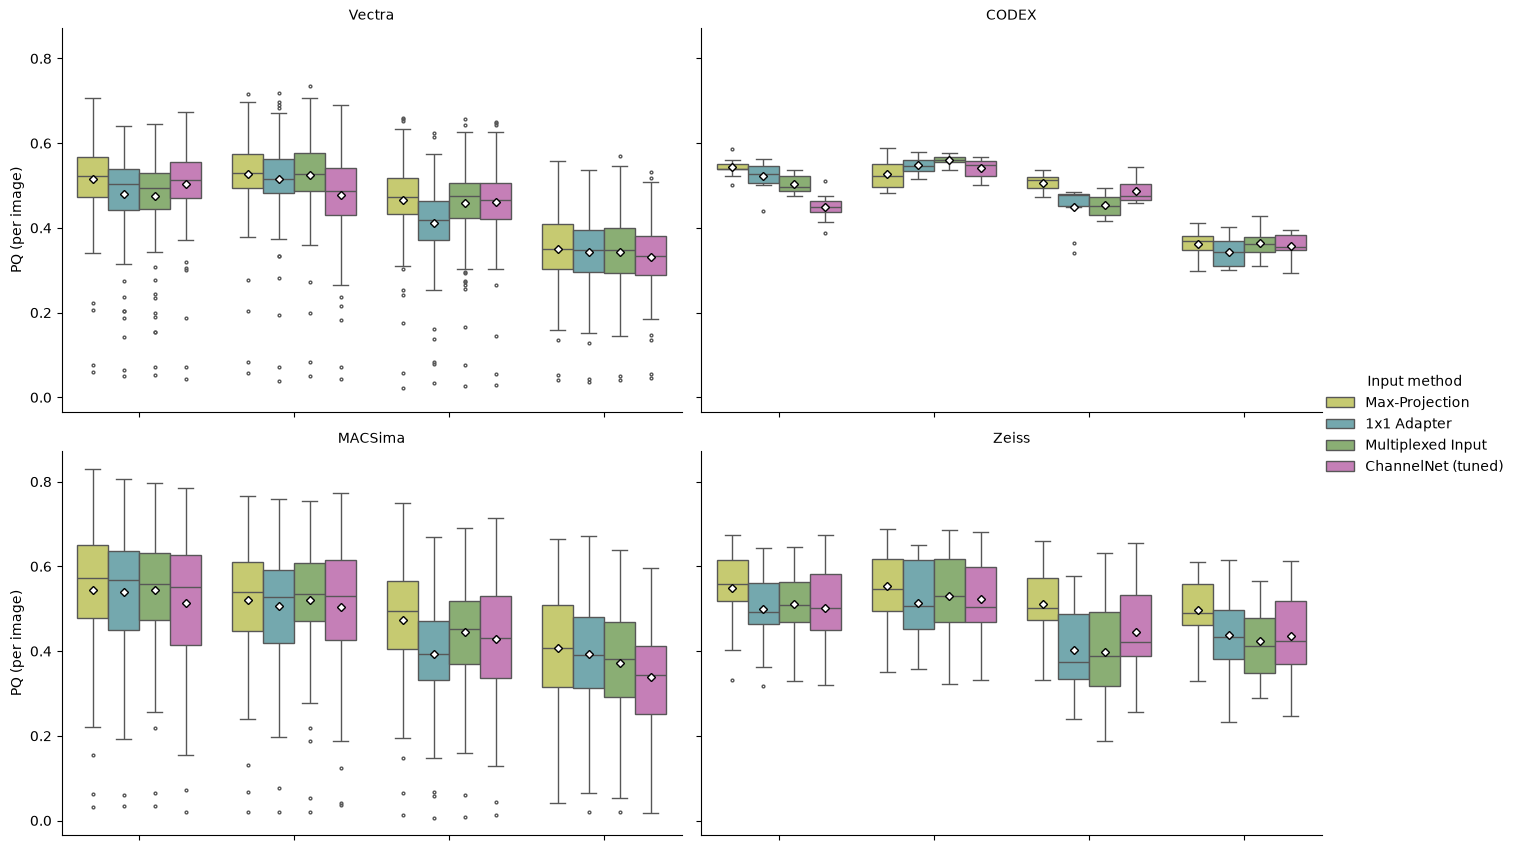

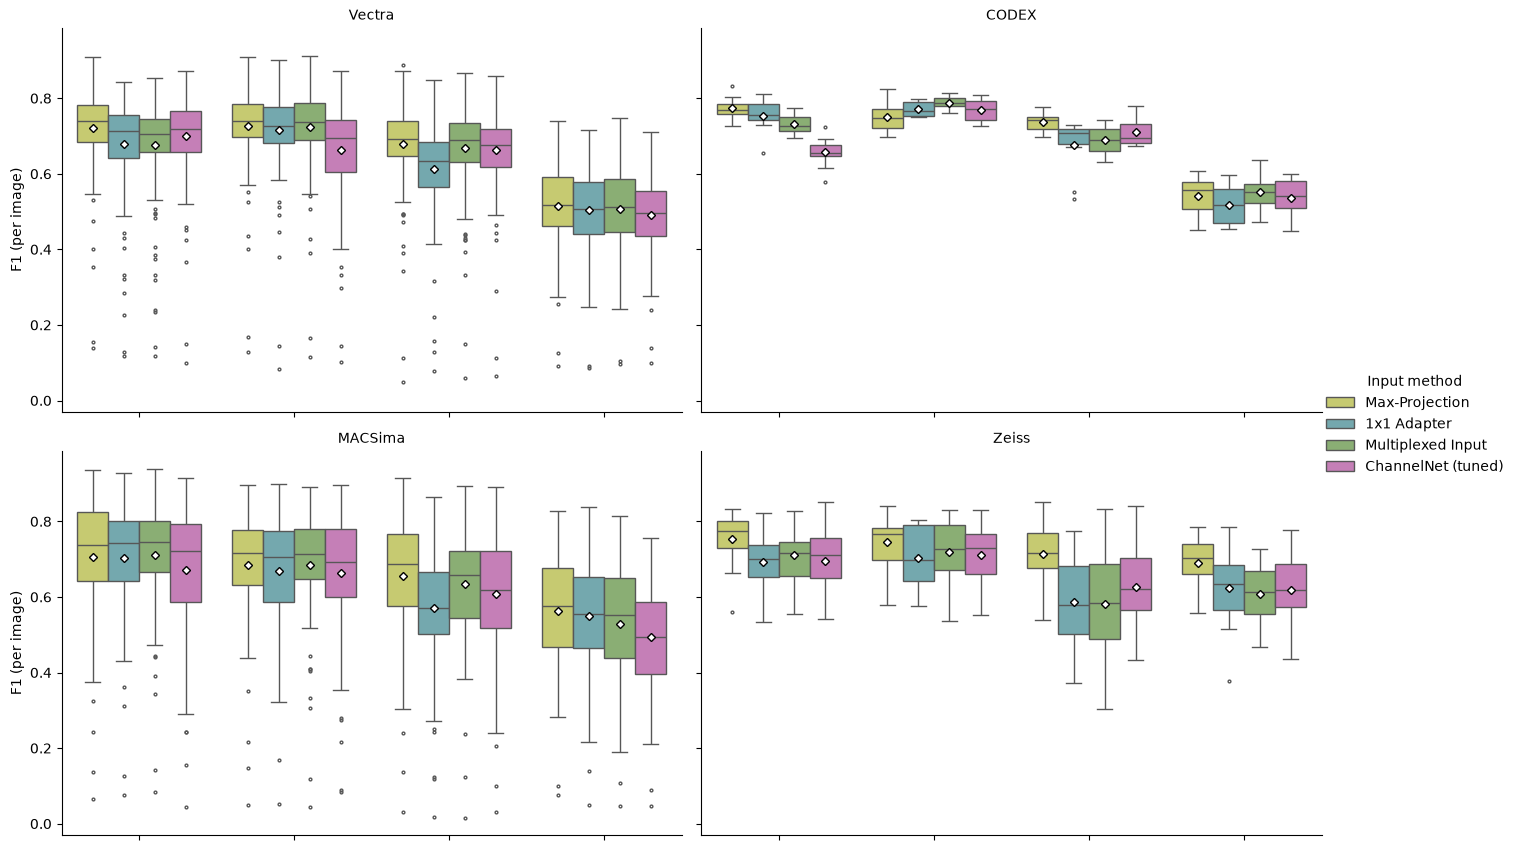

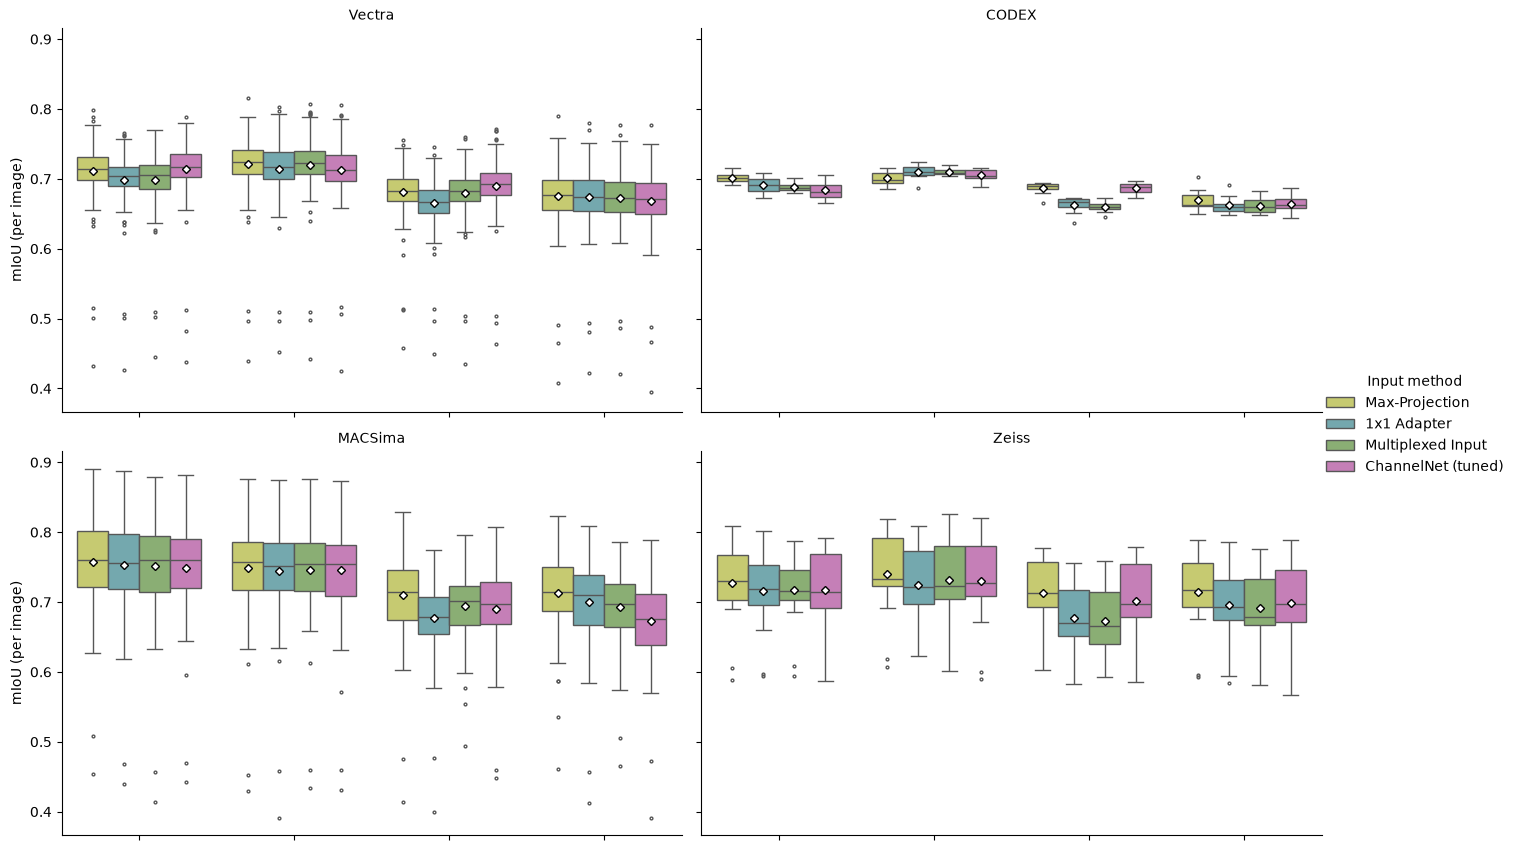

In [5]:
for metric in METRICS:
    g = sns.catplot(
        data=scores, kind="box", x="Model", y=metric, hue="Modality", col="Dataset",
        order=MODEL_ORDER, hue_order=MODALITY_ORDER, col_order=DATASETS, col_wrap=2, palette=PALETTE,
        showmeans=True, meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=4),
        fliersize=2, height=4.5, aspect=1.5,
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("", f"{metric} (per image)")
    g.set_xticklabels(rotation=20)
    for text in g.legend.texts:
        text.set_text(MODALITY_LABELS[text.get_text()])
    g.legend.set_title("Input method")
    g.savefig(EXPORT_DIR / f"Modality_ByDataset_{metric}.pdf", bbox_inches="tight")